# 2. Patrón estacional con residual AR(1) bayesiano


## Pregunta

¿Cómo separar el patrón solar esperado de las desviaciones temporales y generar semanas futuras plausibles?

Usamos

$$y_t=m_t+r_t,$$

$$m_t=\beta_0+s_{diario}(t)+s_{anual}(t),$$

$$r_t=\phi r_{t-1}+\varepsilon_t,\qquad \varepsilon_t\sim N(0,\sigma^2).$$

Equivalentemente:

$$y_t=m_t+\phi(y_{t-1}-m_{t-1})+\varepsilon_t.$$

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

SEED=20260917; rng=np.random.default_rng(SEED)

df=pd.read_csv("data/solar_8760h.csv"); df["time"]=pd.date_range("2019-01-01",periods=len(df),freq="h"); df=df.set_index("time")
y=df.pv_kw_per_kwp.to_numpy(float); H=168; cutoff=len(y)-H
print("Entrenamiento:",df.index[0],"a",df.index[cutoff-1],"| Prueba:",df.index[cutoff],"a",df.index[-1])


Entrenamiento: 2019-01-01 00:00:00 a 2019-12-24 23:00:00 | Prueba: 2019-12-25 00:00:00 a 2019-12-31 23:00:00


## 1. Construcción de $m_t$

Con dos armónicos diarios y uno anual:

$$\begin{aligned}
m_t={}&\beta_0
+\beta_1\sin(2\pi h_t/24)+\beta_2\cos(2\pi h_t/24)\\
&+\beta_3\sin(4\pi h_t/24)+\beta_4\cos(4\pi h_t/24)\\
&+\beta_5\sin(2\pi d_t/365)+\beta_6\cos(2\pi d_t/365).
\end{aligned}$$

El primer par describe una vuelta diaria; el segundo corrige la forma. El par anual permite desplazar libremente el máximo estacional.

In [2]:
def design(index):
    h=index.hour.to_numpy(); d=index.dayofyear.to_numpy()
    return np.column_stack([
        np.ones(len(index)),
        np.sin(2*np.pi*h/24),np.cos(2*np.pi*h/24),
        np.sin(4*np.pi*h/24),np.cos(4*np.pi*h/24),
        np.sin(2*np.pi*d/365),np.cos(2*np.pi*d/365),
    ])

X=design(df.index)
names=["beta0","sin_h1","cos_h1","sin_h2","cos_h2","sin_anual","cos_anual"]


## 2. Priors

Usamos priors deliberadamente sencillos:

$$\beta_j\sim N(0,1),$$

$$\phi\sim N(0,0.5^2)\,\mathbb{I}(-1<\phi<1),$$

$$\sigma\sim\operatorname{HalfNormal}(0.5).$$

La truncación de $\phi$ garantiza un AR(1) estacionario. Estos priors no son universales: se revisan mediante simulación predictiva a priori.

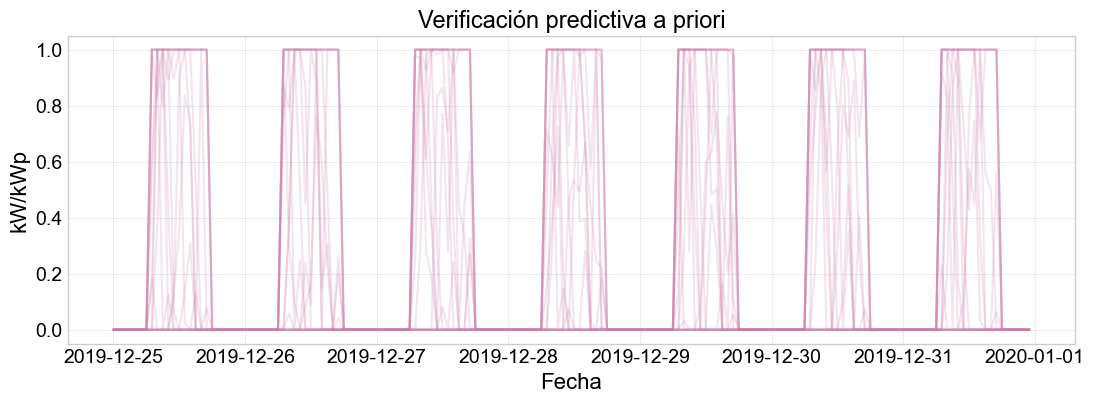

In [3]:
# Máscara física día/noche construida solo con entrenamiento.
train = df.iloc[:cutoff]; tmp=train.assign(month=train.index.month,hour_of_day=train.index.hour)
daylight = tmp.groupby(["month","hour_of_day"])["ghi_kw_m2"].median()
test_index = df.index[cutoff:]
def enforce_physics(values,index):
    out=np.clip(np.asarray(values,float),0,1)
    for j,ts in enumerate(index):
        if daylight.loc[(ts.month,ts.hour)]<=.01: out[j]=0.
    return out

def draw_trunc_phi(rng,mean=0,sd=.5):
    return truncnorm.rvs((-1-mean)/sd,(1-mean)/sd,loc=mean,scale=sd,random_state=rng)

def simulate(beta,phi,sigma,X_future,r_last,rng):
    path=[]; r_now=r_last
    for row in X_future:
        r_now=phi*r_now+rng.normal(0,sigma)
        path.append(row@beta+r_now)
    return np.asarray(path)

# Predictiva a priori para la semana reservada.
prior_paths=[]
for _ in range(100):
    beta=rng.normal(0,1,len(names)); phi=draw_trunc_phi(rng); sigma=abs(rng.normal(0,.5))
    prior_paths.append(enforce_physics(simulate(beta,phi,sigma,X[cutoff:],0,rng),test_index))
prior_paths=np.asarray(prior_paths)

fig,ax=plt.subplots(figsize=(13,4))
for s in range(20): ax.plot(test_index,prior_paths[s],alpha=.2,color="#CC79A7")
ax.set(title="Verificación predictiva a priori",ylabel="kW/kWp",xlabel="Fecha"); plt.show()

**Discusión del prior predictivo:** el prior permite curvas muy extremas. Esto hace visible que $N(0,1)$ para todos los coeficientes y `HalfNormal(0.5)` para la escala son priors amplios en la escala de kW/kWp. Sirven para enseñar, pero una aplicación podría usar conocimiento físico para concentrarlos.

## 3. Posterior mediante Gibbs con un paso Metropolis

Condicionalmente a $\phi$:

$$y_t-\phi y_{t-1}=(x_t-\phi x_{t-1})^T\beta+\varepsilon_t.$$

Esto permite muestrear $\beta$ de una normal multivariada. Condicionalmente a $\beta$, el residual sigue una regresión AR(1), por lo que $\phi$ tiene una normal truncada. Para $\sigma$ usamos un paso Metropolis en escala logarítmica para conservar exactamente el prior Half-Normal.

In [4]:
X0=X[:cutoff-1]; X1=X[1:cutoff]; y0=y[:cutoff-1]; y1=y[1:cutoff]
# Productos cruzados: evitan reconstruir una matriz grande en cada iteración.
A=X1.T@X1; B=X1.T@X0; C=X0.T@X0
d=X1.T@y1; e=X1.T@y0; f=X0.T@y1; g=X0.T@y0

def sample_beta(phi,sigma,rng):
    ZTZ=A-phi*(B+B.T)+phi**2*C
    ZTw=d-phi*(e+f)+phi**2*g
    V=np.linalg.inv(np.eye(X.shape[1])+ZTZ/sigma**2)
    mean=V@(ZTw/sigma**2)
    return rng.multivariate_normal(mean,V)

def sample_phi(beta,sigma,rng):
    resid=y[:cutoff]-X[:cutoff]@beta; r0=resid[:-1]; r1=resid[1:]
    var=1/(r0@r0/sigma**2+1/.5**2); mean=var*(r0@r1/sigma**2)
    sd=np.sqrt(var)
    return truncnorm.rvs((-1-mean)/sd,(1-mean)/sd,loc=mean,scale=sd,random_state=rng)

def log_sigma_cond(log_sigma,beta,phi):
    sigma=np.exp(log_sigma); resid=y[:cutoff]-X[:cutoff]@beta
    innovations=resid[1:]-phi*resid[:-1]; n=len(innovations); sse=innovations@innovations
    # verosimilitud + HalfNormal(0.5) + Jacobiano de sigma=exp(log_sigma)
    return -n*np.log(sigma)-sse/(2*sigma**2)-sigma**2/(2*.5**2)+log_sigma

def run_chain(seed,n_iter=5000,burn=1500,thin=5):
    rr=np.random.default_rng(seed); beta=np.zeros(X.shape[1]); phi=.5; sigma=.1
    kept=[]; accepted=0; step=.025
    for it in range(n_iter):
        beta=sample_beta(phi,sigma,rr); phi=sample_phi(beta,sigma,rr)
        old=np.log(sigma); proposal=old+rr.normal(0,step)
        if np.log(rr.random())<log_sigma_cond(proposal,beta,phi)-log_sigma_cond(old,beta,phi):
            sigma=np.exp(proposal); accepted+=1
        if it>=burn and (it-burn)%thin==0: kept.append(np.r_[beta,phi,sigma])
    return np.asarray(kept),accepted/n_iter

chain1,acc1=run_chain(SEED); chain2,acc2=run_chain(SEED+100)
draws=np.vstack([chain1,chain2])
print("Muestras posteriores:",len(draws),"| aceptación sigma:",round(acc1,3),round(acc2,3))

Muestras posteriores: 1400 | aceptación sigma: 0.34 0.356


,media,q05,q95
beta0,0.2103,0.2056,0.2149
sin_h1,0.0032,-0.0001,0.0065
cos_h1,-0.3387,-0.3419,-0.3355
sin_h2,-0.0065,-0.0084,-0.0047
cos_h2,0.1611,0.1593,0.1629
sin_anual,0.0267,0.0201,0.0333
cos_anual,0.0064,-0.0002,0.0131
phi,0.8618,0.8526,0.8708
sigma,0.0360,0.0356,0.0365


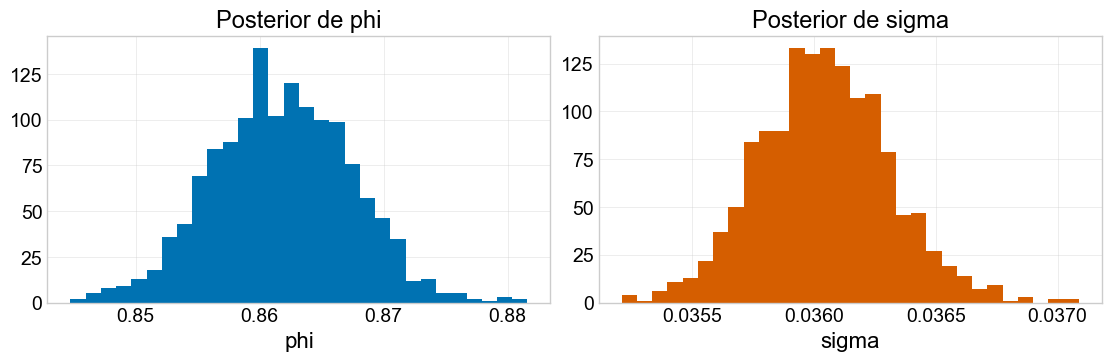

In [5]:
posterior=pd.DataFrame({
    "media":draws.mean(0),"q05":np.quantile(draws,.05,axis=0),"q95":np.quantile(draws,.95,axis=0)
},index=names+["phi","sigma"])
display(posterior.round(4))

fig,axes=plt.subplots(1,2,figsize=(11,3.5),constrained_layout=True)
axes[0].hist(draws[:,-2],bins=30,color="#0072B2"); axes[0].set(title="Posterior de phi",xlabel="phi")
axes[1].hist(draws[:,-1],bins=30,color="#D55E00"); axes[1].set(title="Posterior de sigma",xlabel="sigma")
plt.show()

## 4. Predictiva posterior

Para cada escenario:

1. tomamos $(\beta^{(s)},\phi^{(s)},\sigma^{(s)})$ de la posterior;
2. calculamos el último residual de entrenamiento;
3. simulamos recursivamente $r_{T+1:T+168}^{(s)}$;
4. sumamos el patrón $m_t^{(s)}$;
5. aplicamos noche igual a cero y límites $[0,1]$.

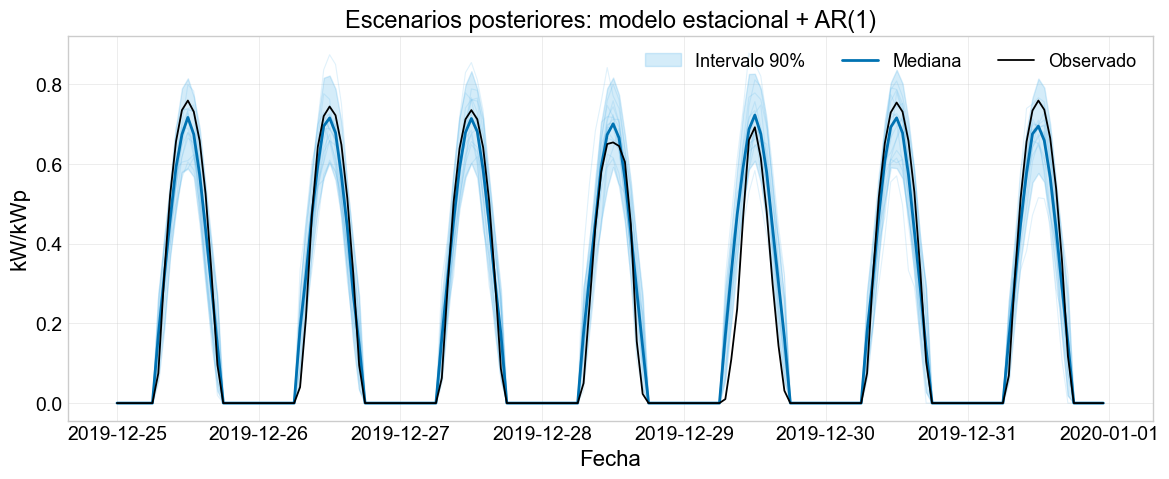

In [6]:
N_SCENARIOS=100; chosen=rng.choice(len(draws),N_SCENARIOS,replace=False); scenarios=[]
for j in chosen:
    beta=draws[j,:len(names)]; phi=draws[j,-2]; sigma=draws[j,-1]
    r_last=y[cutoff-1]-X[cutoff-1]@beta
    path=simulate(beta,phi,sigma,X[cutoff:],r_last,rng)
    scenarios.append(enforce_physics(path,test_index))
scenarios=np.asarray(scenarios); observed=y[cutoff:]
median=np.median(scenarios,0); q05,q95=np.quantile(scenarios,[.05,.95],axis=0)

fig,ax=plt.subplots(figsize=(14,5))
for s in range(15): ax.plot(test_index,scenarios[s],color="#56B4E9",alpha=.18,lw=.8)
ax.fill_between(test_index,q05,q95,color="#56B4E9",alpha=.25,label="Intervalo 90%")
ax.plot(test_index,median,color="#0072B2",lw=2,label="Mediana")
ax.plot(test_index,observed,color="black",lw=1.3,label="Observado")
ax.set(title="Escenarios posteriores: modelo estacional + AR(1)",ylabel="kW/kWp",xlabel="Fecha"); ax.legend(ncol=3)
fig.savefig("Figures/forecast_bayes_estacional_ar1.pdf", dpi=220, bbox_inches="tight")
plt.show()

In [7]:
def mae(a,b): return np.mean(np.abs(a-b))
def rmse(a,b): return np.sqrt(np.mean((a-b)**2))
naive=y[cutoff-H:cutoff]
results=pd.DataFrame({"MAE":[mae(observed,naive),mae(observed,median)],"RMSE":[rmse(observed,naive),rmse(observed,median)],"Cobertura_90":[np.nan,np.mean((observed>=q05)&(observed<=q95))]},index=["Semana anterior","Estacional + AR(1) Bayes"])
display(results.round(4))
print("Energía observada:",round(observed.sum(),2),"kWh/kWp")
print("Mediana predictiva de energía:",round(np.median(scenarios.sum(axis=1)),2),"kWh/kWp")

out=(pd.DataFrame(scenarios,columns=np.arange(1,H+1)).rename_axis("scenario").reset_index()
     .assign(scenario=lambda x:x.scenario+1)
     .melt(id_vars="scenario",var_name="time",value_name="pv_kw_per_kwp"))
out["timestamp"]=out.time.map(dict(enumerate(test_index,start=1)))
out["probability"]=1/N_SCENARIOS
out=out[["scenario","time","timestamp","pv_kw_per_kwp","probability"]]
output_dir=Path("material_dia2") if Path("series_temporales").exists() else Path.cwd()
output_path=output_dir/"escenarios_solares_estacional_ar1_168h.csv"
out.to_csv(output_path,index=False)
print("Escenarios exportados:",output_path.resolve())

,MAE,RMSE,Cobertura_90
Semana anterior,0.0349,0.0816,NaN
Estacional + AR(1) Bayes,0.0306,0.0549,0.9405


Energía observada: 34.86 kWh/kWp
Mediana predictiva de energía: 35.3 kWh/kWp
Escenarios exportados: /Users/marialuisadaza/Library/CloudStorage/GoogleDrive-mdazatorres@cimat.mx/My Drive/Cursillos/Curso Energia Renovables/material_dia2/notebooks/escenarios_solares_estacional_ar1_168h.csv


## 5. Qué aprendimos

- $m_t$ representa lo repetitivo y explicable por calendario.
- $r_t$ representa desviaciones persistentes respecto a ese patrón.
- $\phi$ controla memoria: cerca de cero, memoria corta; cerca de uno, alta persistencia.
- $\sigma$ controla variabilidad nueva.
- Los escenarios propagan incertidumbre en parámetros y observaciones.
- La normalidad y el recorte posterior son simplificaciones; un modelo acotado o de dos partes sería una extensión natural.